In [8]:
import pandas as pd 
main=pd.read_csv("C:/Users/shrut/Desktop/PLAYSTORE_NLP/VS_CODE/main.csv")

In [9]:
main.head(10)

,Unnamed: 0,content,score,at,thumbsUpCount,app_name,category,label
0,0,i have ordered items from this app a few times...,2,2026-07-25 14:09:53,4,Flipkart,Shopping,0
1,1,I have been facing the same issue for the last...,1,2026-07-30 22:59:36,3,Flipkart,Shopping,0
2,2,Very disappointing experience with Flipkart. I...,1,2026-07-31 03:20:40,3,Flipkart,Shopping,0
3,3,Long term user. App is good. but recent days s...,1,2026-07-29 11:52:22,4,Flipkart,Shopping,0
4,4,"I ordered a mobile cover on 26 July, and the e...",1,2026-08-04 13:07:44,1,Flipkart,Shopping,0
5,5,: I have always had a great experience shoppin...,5,2026-08-03 07:05:11,2,Flipkart,Shopping,1
6,6,Pathetic online shopping app. Deliveries are n...,1,2026-07-29 19:20:14,5,Flipkart,Shopping,0
7,7,This is honestly the worst service I have ever...,1,2026-08-02 13:46:50,2,Flipkart,Shopping,0
8,8,Flipkart is the worst shopping app. I purchase...,1,2026-07-30 09:14:04,3,Flipkart,Shopping,0
9,9,Worst experience with this app. It's been so m...,1,2026-08-06 22:23:50,0,Flipkart,Shopping,0


In [10]:
df=pd.read_csv("C:/Users/shrut/Desktop/PLAYSTORE_NLP/final_ml_1lakh(after_lem_stop).csv")

In [11]:
df.head(10)

,review_text,actual_sentiment,predicted_probability,predicted_sentiment,is_correct,app_name,app_category,split_type
0,even enter account though get otp 2 second sti...,0,0.013999,0,True,Paytm,FinTech,Train
1,regard amazon pay later get like 100 spam call...,0,0.011150,0,True,Amazon India,Shopping,Train
2,disappointed instagrams account verification p...,0,0.040020,0,True,Instagram,Social,Train
3,ive use phonepe think great app however id lik...,1,0.943962,1,True,PhonePe,FinTech,Train
4,super useful would recommend love choose wheth...,1,0.998546,1,True,TickTick,Productivity,Train
5,day day service amazon deteriorate despite tak...,0,0.007424,0,True,Amazon India,Shopping,Train
6,one best personal business task management app...,1,0.999840,1,True,Todoist,Productivity,Train
7,bad experience ive place order milk product ca...,0,0.036271,0,True,Zepto,Delivery,Train
8,download use app review fake im tell experienc...,0,0.010825,0,True,PhonePe,FinTech,Train
9,take time payment payment history button handy...,0,0.506012,1,False,Google Pay,FinTech,Train


In [30]:
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS, TfidfVectorizer

# 1. Main Dataframe Load Karein

# 2. Generic App Noise Stopwords (Lekin Customer Support & Care bilkul INCLUDED hain)
generic_noise = [
    "app",
    "use",
    "bad",
    "worst",
    "good",
    "experience",
    "try",
    "work",
    "open",
    "dont",
    "know",
    "time",
    "ive",
    "year",
    "make",
    "problem",
    "issue",
    "using",
    "fix",
    "update",
    "google",
    "pay",
    "flipkart",
    "amazon",
    "paytm",
    "phonepe",
    "zepto",
    "zomato",
    "swiggy",
]
custom_stopwords = list(ENGLISH_STOP_WORDS.union(generic_noise))

# Column Initialize Karein
df["global_cluster_id"] = -1

global_counter = 1
summary_list = []

categories = df["app_category"].dropna().unique()

print("K-Means Clustering shuru ho rahi hai...\n")

# 3. Category-wise TF-IDF + K-Means Fit
for category in categories:
    cat_mask = (df["app_category"] == category) & (
        df["predicted_sentiment"] == 0
    )
    cat_indices = df[cat_mask].index

    if len(cat_indices) < 5:
        continue

    # Vectorize
    vectorizer = TfidfVectorizer(
        max_features=1000, stop_words=custom_stopwords, ngram_range=(2, 3)
    )
    X_tfidf = vectorizer.fit_transform(
        df.loc[cat_indices, "review_text"].fillna("")
    )

    # K-Means (K=4 per category)
    NUM_CLUSTERS = 4
    kmeans = KMeans(n_clusters=NUM_CLUSTERS, random_state=42, n_init=10)
    local_clusters = kmeans.fit_predict(X_tfidf)

    # Continuous Global IDs Assign Karein (1, 2, 3, 4, 5...)
    global_clusters = local_clusters + global_counter
    df.loc[cat_indices, "global_cluster_id"] = global_clusters

    # Inspection Data Collect Karein
    terms = vectorizer.get_feature_names_out()
    order_centroids = kmeans.cluster_centers_.argsort()[:, ::-1]

    for local_id in range(NUM_CLUSTERS):
        g_id = global_counter + local_id
        top_words = [terms[ind] for ind in order_centroids[local_id, :4]]
        count = (df["global_cluster_id"] == g_id).sum()

        summary_list.append({
            "Category": category,
            "Global_Cluster_ID": g_id,
            "Total_Reviews": count,
            "Top_Keywords": ", ".join(top_words),
        })

    global_counter += NUM_CLUSTERS


# Summary Table Print Karein
summary_df = pd.DataFrame(summary_list)
print("=== GENERATED CLUSTERS SUMMARY ===")
print(summary_df.to_string(index=False))

K-Means Clustering shuru ho rahi hai...

=== GENERATED CLUSTERS SUMMARY ===
    Category  Global_Cluster_ID  Total_Reviews                                                                          Top_Keywords
    Shopping                  1            641            customer support, contact customer support, contact customer, support team
    Shopping                  2            782             customer care, contact customer care, care service, customer care service
    Shopping                  3            581   customer service, contact customer service, contact customer, poor customer service
    Shopping                  4           3724                                place order, cancel order, order product, order cancel
Media_Travel                  5             59                                 live match, watch live, watch live match, live stream
Media_Travel                  6            149                           jio cinema, watch movie, premium subscription, movie 

In [31]:
df.head(30)

,review_text,actual_sentiment,predicted_sentiment,predicted_probability,app_name,app_category,kmeans_cluster_id,core_complaint_label,global_cluster_id
0,bad service could give less 1 start could give...,0,0,0.006361,Nykaa,Shopping,0,Customer Support Reachability,4
1,poor assistance due ai ask refund policy initi...,0,0,0.059878,MakeMyTrip,Media_Travel,2,General Media/Travel Issues,7
2,typical google enshitification update make bas...,0,0,0.128227,YouTube,Social,1,General Social Media Issues,10
3,take less 10 minute receive item order blinkit...,1,1,0.980230,Blinkit,Delivery,-1,Positive_Feedback,-1
4,best app purchase discount low amount product ...,1,1,0.998118,Meesho,Shopping,-1,Positive_Feedback,-1
5,disappointing experience place order last 3 da...,0,0,0.009105,Amazon India,Shopping,2,Order Placement & Cancellation,4
6,experience bad although product good rate also...,0,0,0.029523,Nykaa,Shopping,0,Customer Support Reachability,4
7,dont purchase online amazon return policy comp...,0,0,0.012408,Amazon India,Shopping,0,Return & Refund Issues,4
8,clear delete chat whole message delete chat me...,0,0,0.038124,WhatsApp,Social,1,General Social Media Issues,10
9,unreliable service poor resolution protocol ex...,0,0,0.011284,Swiggy,Delivery,0,Support Escalation Bottlenecks,13


In [24]:
df.to_csv("C:/Users/shrut/Desktop/PLAYSTORE_NLP/with_complain.csv")

C:\Users\shrut\AppData\Local\Temp\ipykernel_16512\2734975353.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


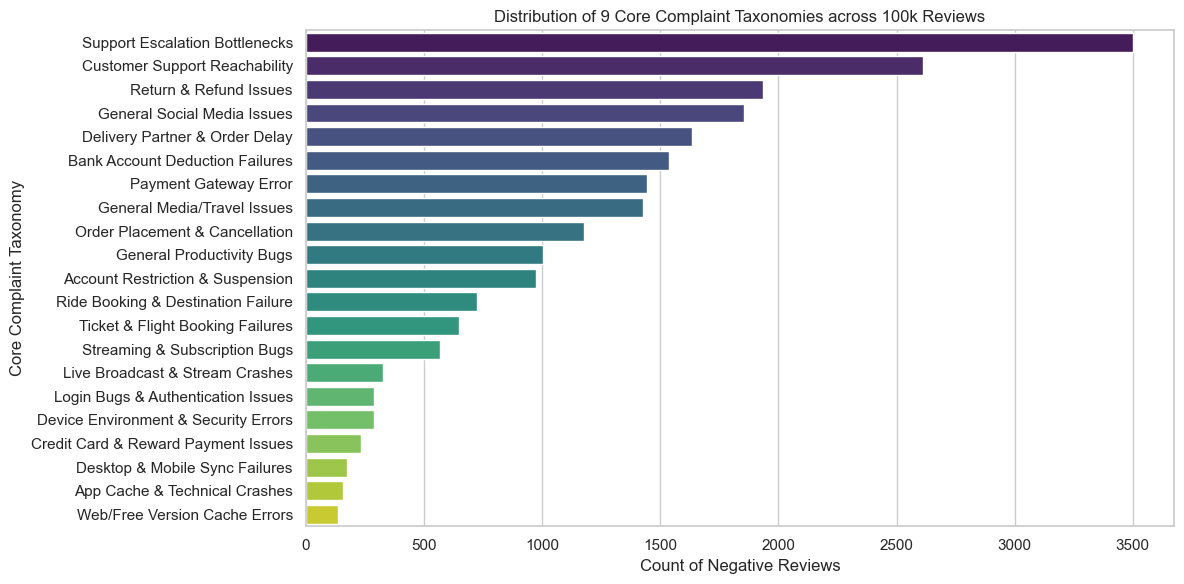

<Figure size 1400x800 with 0 Axes>

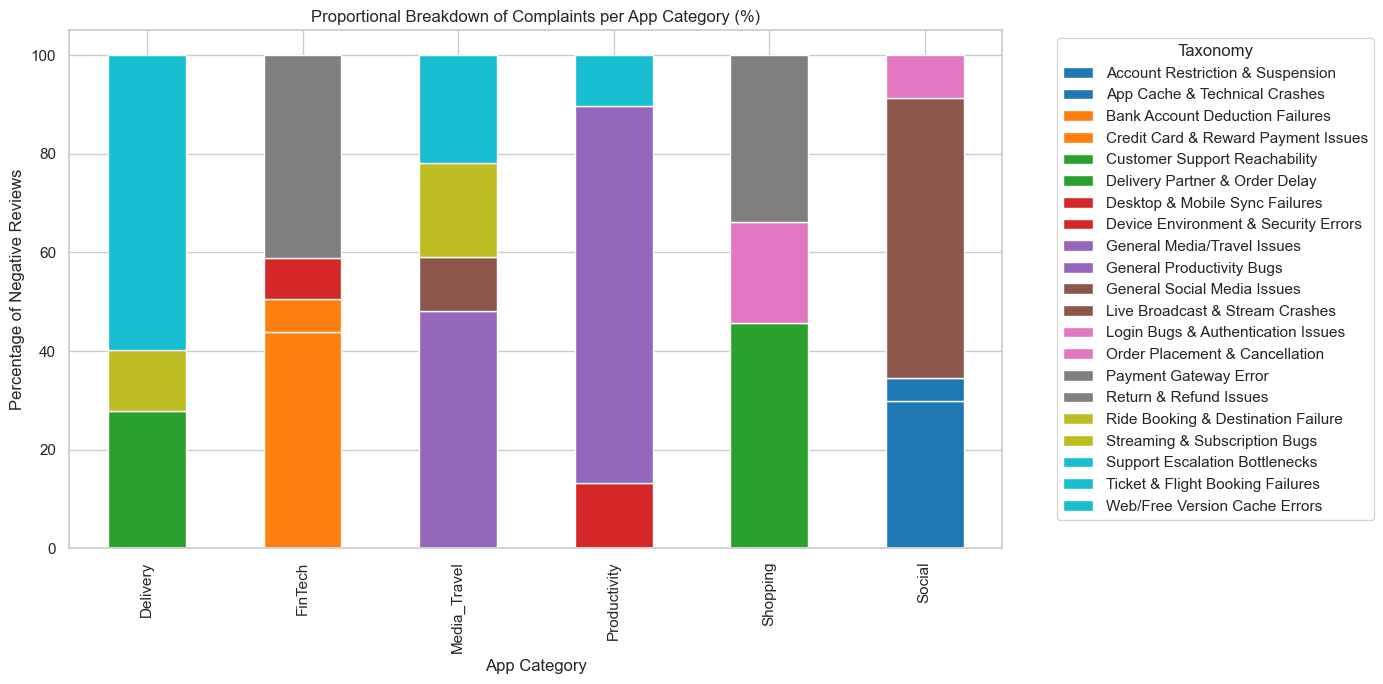

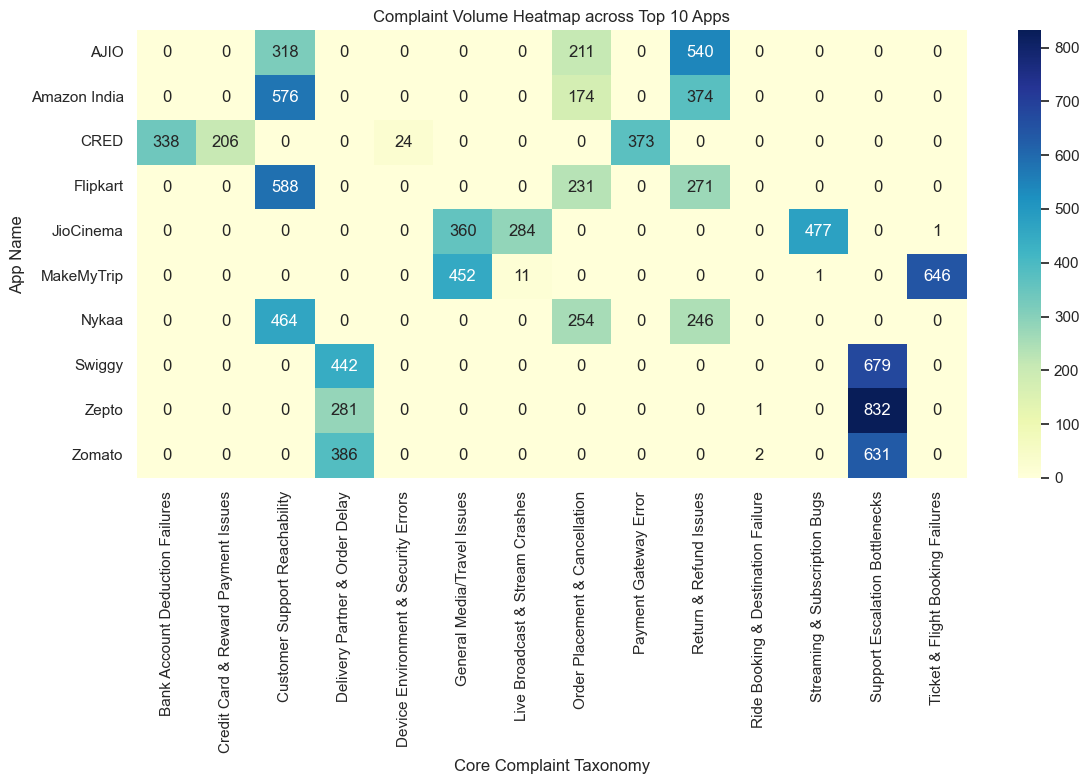

All plots saved in the 'github_plots' directory!


In [28]:
import os
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Set style
sns.set_theme(style="whitegrid")
plt.rcParams.update({"font.size": 12, "figure.autolayout": True})

# Load the final mapped CSV
df = pd.read_csv(r"C:\Users\shrut\Desktop\PLAYSTORE_NLP\with_complain.csv")

# Filter negative reviews
neg_df = df[df["predicted_sentiment"] == 0].copy()

os.makedirs("github_plots", exist_ok=True)

# 1. Overall Complaint Taxonomy Distribution
plt.figure(figsize=(12, 6))
order = neg_df["core_complaint_label"].value_counts().index
ax = sns.countplot(
    data=neg_df, y="core_complaint_label", order=order, palette="viridis"
)
plt.title("Distribution of 9 Core Complaint Taxonomies across 100k Reviews")
plt.xlabel("Count of Negative Reviews")
plt.ylabel("Core Complaint Taxonomy")
plt.savefig(
    "github_plots/1_overall_complaints.png", dpi=300, bbox_inches="tight"
)
plt.show()

# 2. Stacked Bar Chart: Category vs Complaint Taxonomy
plt.figure(figsize=(14, 8))
cross_tab = pd.crosstab(
    neg_df["app_category"], neg_df["core_complaint_label"], normalize="index"
) * 100
cross_tab.plot(kind="bar", stacked=True, colormap="tab10", figsize=(14, 7))
plt.title("Proportional Breakdown of Complaints per App Category (%)")
plt.xlabel("App Category")
plt.ylabel("Percentage of Negative Reviews")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", title="Taxonomy")
plt.savefig(
    "github_plots/2_category_complaint_breakdown.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

# 3. Top Apps by Specific Complaints (Heatmap)
plt.figure(figsize=(12, 8))
top_apps = neg_df["app_name"].value_counts().head(10).index
app_df = neg_df[neg_df["app_name"].isin(top_apps)]
pivot_app = pd.crosstab(app_df["app_name"], app_df["core_complaint_label"])

sns.heatmap(pivot_app, annot=True, fmt="d", cmap="YlGnBu", cbar=True)
plt.title("Complaint Volume Heatmap across Top 10 Apps")
plt.xlabel("Core Complaint Taxonomy")
plt.ylabel("App Name")
plt.savefig("github_plots/3_app_complaint_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

print("All plots saved in the 'github_plots' directory!")